In [3]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score , classification_report

data = pd.read_csv("../data/output.csv")
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"],errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(0)
data = pd.get_dummies(data,drop_first=True)

X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

X_train,X_test,y_train,y_test = train_test_split(X , y , test_size = 0.2 , random_state = 1 , stratify=y)
best_model = joblib.load("../models/random_forest.pkl")

y_pred_final = best_model.predict(X_test)

print(y_pred_final[:10])

[False  True  True False False  True False  True  True False]


In [4]:
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))

print("\nclassification report :")
print(classification_report(y_test , y_pred_final))


Accuracy : 0.7444996451383961
Precision: 0.5126353790613718
Recall   : 0.7593582887700535
F1 Score : 0.6120689655172413

classification report :
              precision    recall  f1-score   support

       False       0.89      0.74      0.81      1035
        True       0.51      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.76      1409



In [5]:
final_predictions = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred_final})
print(final_predictions)


      Actual  Predicted
0      False      False
1       True       True
2      False       True
3      False      False
4      False      False
...      ...        ...
1404   False      False
1405   False       True
1406    True       True
1407   False      False
1408   False      False

[1409 rows x 2 columns]


In [6]:
final_predictions.to_csv("../data/final_prediction.csv" , index = False)

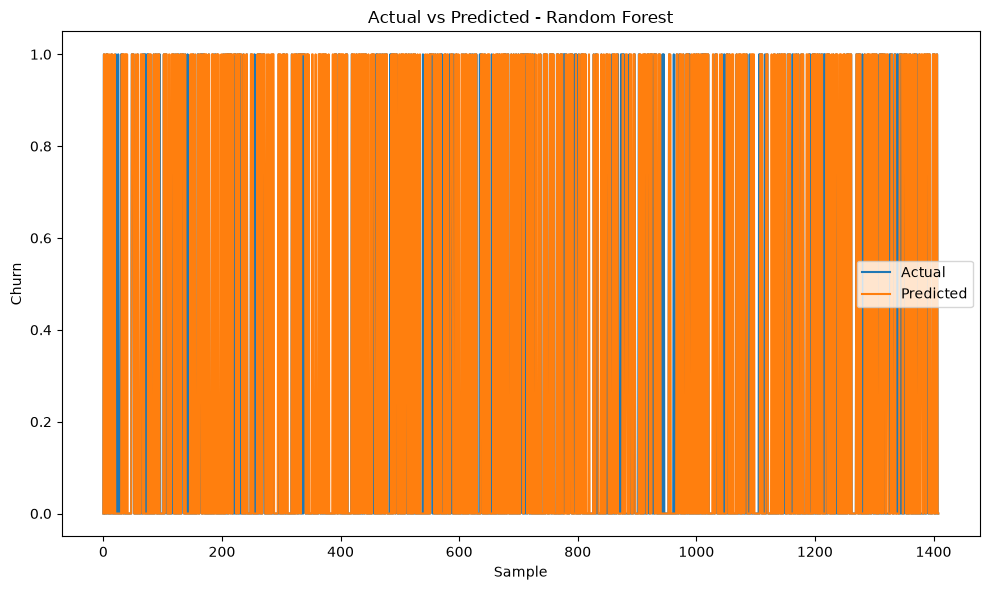

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10 ,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_final, label="Predicted")

plt.xlabel("Sample")
plt.ylabel("Churn")
plt.title("Actual vs Predicted - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()